## Data Profiler : Data Preprocessing & Feature Engineering

**Project:** PR.1 Data Profiler (Red & White Skill Education)
**Objective:** Understand, clean, transform, and analyze a real-world-style customer dataset (assembled from CSV, JSON, SQL, and a REST API source) to frame and prepare a **customer churn prediction** problem.

---

### Part A : Fundamentals

#### 1. What is Data Analysis?

**Data Analysis** is the systematic process of inspecting, cleaning, transforming, and modeling data with the goal of discovering useful information, drawing conclusions, and supporting decision-making.

At a high level, data analysis involves:
- **Collecting** data from one or more sources (files, databases, APIs, sensors).
- **Cleaning** the data — handling missing values, duplicates, and inconsistent formats.
- **Exploring** the data to understand distributions, relationships, and anomalies (EDA).
- **Modeling / Interpreting** the data using statistical or machine learning techniques.
- **Communicating** findings through visualizations, reports, and dashboards.

In a business context, data analysis turns raw, messy, multi-source records into **actionable insight** — for example, identifying *which customers are likely to churn* and *why*.


#### 2. How to Plan a Data Science Project

A data science project is rarely just "build a model." It follows a structured lifecycle, commonly summarized as **CRISP-DM** (Cross-Industry Standard Process for Data Mining), adapted here into practical steps:

1. **Business Understanding :** Define the problem in business terms (e.g., "reduce customer churn"), identify stakeholders, and set success metrics.
2. **Data Understanding :** Identify what data is available, where it lives (CSV, JSON, SQL, APIs), and its quality.
3. **Data Acquisition :** Collect and consolidate data from all relevant sources into a working dataset.
4. **Data Preparation / Cleaning :** Handle missing values, duplicates, incorrect types, and irrelevant fields.
5. **Exploratory Data Analysis (EDA) :** Use univariate, bivariate, and multivariate analysis to understand patterns and relationships.
6. **Feature Engineering :** Create, transform, or select variables that improve model performance (e.g., recency/frequency/monetary features).
7. **Modeling :** Frame and train an appropriate machine learning model (classification, regression, clustering, etc.).
8. **Evaluation :** Validate the model against business goals using appropriate metrics (accuracy, precision/recall, F1, AUC for classification).
9. **Deployment & Monitoring :** Ship the model into production and monitor its performance/data drift over time.
10. **Documentation & Communication :** Document the process (README, reports) and communicate insights to stakeholders.

#### 3. Machine Learning Problem Statement

**Problem Type:** Binary Classification

**Goal:** Predict whether a customer will **churn** (churn = 1) or **stay** (churn = 0), based on their demographic profile, purchase behavior, membership history, and engagement metrics.

**Target variable:** **churn** (binary: 0 = retained, 1 = churned)

**Candidate features:** age, gender, region, income, signup_days_ago, purchase_frequency, total_spent, avg_order_value, last_purchase_days_ago, membership_years, membership_tier, support_tickets, satisfaction_score, app_sessions_per_month, email_open_rate

**Business value:** Once churn-risk customers are identified early, the business can trigger targeted retention campaigns (discounts, outreach, loyalty perks), reducing revenue loss.

This is the ML problem statement that motivates every preprocessing decision made later in this notebook - e.g., we keep **last_purchase_days_ago** and **satisfaction_score** because they are strong behavioral churn signals.


#### 4. What are Tensors?

A **tensor** is a generalized, multi-dimensional array of numbers - the fundamental data structure used to represent inputs, outputs, and parameters in modern machine learning and deep learning frameworks (NumPy, PyTorch, TensorFlow).

Tensors are classified by their **rank** (number of dimensions/axes):

| Rank | Name | Example | Shape |
|------|------|---------|-------|
| 0 | Scalar | a single number, e.g. **7** | **()** |
| 1 | Vector | a list of numbers, e.g. one customer's features | **(n,)** |
| 2 | Matrix | a table of numbers, e.g. our full dataset (rows × columns) | **(rows, cols)** |
| 3+ | N-D Tensor | a stack of matrices, e.g. a batch of images or a batch of customer sequences over time | **(batch, rows, cols)** |

**Why tensors matter in ML/data science:**
- Our cleaned customer table *is* a rank-2 tensor: rows = customers, columns = features.
- Deep learning models operate on batches of such tensors (rank-3+) for efficient parallel computation on GPUs.
- Every mathematical operation in ML (dot products, matrix multiplication, gradients) is defined on tensors.


In [18]:
import numpy as np 

scalar = np.array(42)
print(f"Scslar (rank 0) value : {scalar}")

vector = np.array([24, 70000, 5, 4999]) # [age, salary, purchased_freq, total_spend]
print(f"\nVector (rank 1) --> Value : {vector}, Shape : {vector.shape}, NDim : {vector.ndim}")

matrix = np.array([
    [24, 70000, 5, 4999],
    [22, 40000, 4, 290],
    [35, 60000, 7, 2550]
])
print(f"\nMatrix (rank 2) : \n{matrix}")
print(f"Shape : {matrix.shape}, NDim : {matrix.ndim}")

tensor_3d = np.stack([matrix, matrix * 1.05])
print("\n3D Tensor (rank 3) : 2 batches x 3 customers x 4 features")
print(f"Shape : {tensor_3d.shape}, NDim : {tensor_3d.ndim}")

Scslar (rank 0) value : 42

Vector (rank 1) --> Value : [   24 70000     5  4999], Shape : (4,), NDim : 1

Matrix (rank 2) : 
[[   24 70000     5  4999]
 [   22 40000     4   290]
 [   35 60000     7  2550]]
Shape : (3, 4), NDim : 2

3D Tensor (rank 3) : 2 batches x 3 customers x 4 features
Shape : (2, 3, 4), NDim : 3


---

### Part B : Data Acquisition

Our "customer purchase behavior" dataset is deliberately fragmented across **four different source types**, mirroring a real company where demographic data lives in a CSV export, purchase data comes from a JSON export, membership data lives in a SQL database, and live engagement/churn signals come from a REST API. We import and later merge all four.


In [19]:
import pandas as pd 
import seaborn as sns 
import json
import sqlite3
import matplotlib.pyplot as plt
import requests

#### 1. Load CSV file using pandas

In [20]:
csv_df = pd.read_csv("data/customers_demographics.csv")
print(f"Shape of CSV file : {csv_df.shape}")
csv_df.head()

Shape of CSV file : (1215, 6)


,customer_id,age,gender,income,region,signup_days_ago
0,CUST00001,56.0,Male,32492.66,Central,1596
1,CUST00002,69.0,Male,65881.28,East,1368
2,CUST00003,46.0,Female,70882.00,Central,1020
3,CUST00004,32.0,Other,46862.37,West,1850
4,CUST00005,60.0,Male,46539.24,Central,647


**Interpretation:** The CSV contains **1,215 rows and 6 columns**, providing demographic information such as customer ID, age, gender, income, region, and signup history. This is the largest source at this stage and will provide the base customer list for the final merged dataset.

#### 2. Parse a JSON file

In [21]:
with open("data/purchase_behavior.json") as f:
    json_raw = json.load(f)
    
json_df = pd.DataFrame(json_raw)
print(f"Shape od JSON file : {json_df.shape}")
json_df.head()

Shape od JSON file : (1200, 5)


,customer_id,purchase_frequency,total_spent,avg_order_value,last_purchase_days_ago
0,CUST00001,5,424.90,84.98,162
1,CUST00002,4,3648.65,912.16,16
2,CUST00003,8,5388.97,673.62,21
3,CUST00004,1,0.00,0.00,35
4,CUST00005,6,6479.58,1079.93,141


**Interpretation:** The JSON file contains **1,200 records and 5 columns** related to customer purchase behavior. It provides frequency, total spending, average order value, and recency information that can help explain customer engagement and churn.

#### 3. Connect to SQL & Fetch records

In [22]:
conn = sqlite3.connect("data/customers.db")
sql_df = pd.read_sql_query("SELECT * FROM customer_membership", conn)
conn.close()

print(f"Shape of SQL file : {sql_df.shape}")
sql_df.head()

Shape of SQL file : (1200, 5)


,customer_id,membership_years,membership_tier,support_tickets,satisfaction_score
0,CUST00001,5,Silver,2,1.2
1,CUST00002,3,Silver,1,3.3
2,CUST00003,0,Silver,1,1.9
3,CUST00004,1,Silver,1,4.8
4,CUST00005,3,Gold,4,3.7


**Interpretation:** The SQL source contains **1,200 records and 5 columns** describing membership and support information. These variables add customer loyalty and service-experience context to the demographic and purchase data.

#### 4.1 Fetch data from API

In [23]:
api = "https://jsonplaceholder.typicode.com/posts"
res = requests.get(api)

if res.status_code == 200:
    data = res.json()
    api_df = pd.DataFrame(data)
    print(f"Shape of API data : {api_df.shape}")
    print(api_df.head())

Shape of API data : (100, 4)
   userId  id                                              title  \
0       1   1  sunt aut facere repellat provident occaecati e...   
1       1   2                                       qui est esse   
2       1   3  ea molestias quasi exercitationem repellat qui...   
3       1   4                               eum et est occaecati   
4       1   5                                 nesciunt quas odio   

                                                body  
0  quia et suscipit\nsuscipit recusandae consequu...  
1  est rerum tempore vitae\nsequi sint nihil repr...  
2  et iusto sed quo iure\nvoluptatem occaecati om...  
3  ullam et saepe reiciendis voluptatem adipisci\...  
4  repudiandae veniam quaerat sunt sed\nalias aut...  


**Interpretation:** The API request successfully returned **100 records with 4 fields**. This demonstrates API-based data acquisition. The returned public API data is not the final customer-engagement dataset used for the churn analysis; the notebook later loads the prepared offline API response containing the required customer-level engagement and churn fields.

#### 4.2 Fetching Images from Pixabay API KEY

In [24]:
API_KEY = "57022422-14955828ba00322cac36b424e"
api = f"https://pixabay.com/api/?key={API_KEY}&q=CherryRed+Heels&image_type=photo"

res = requests.get(api)

if res.status_code == 200:
    data = res.json()
    all_images = data["hits"]
    
    for i in all_images:
        print(i["largeImageURL"])
        print("="*50)

https://pixabay.com/get/g0920f07e796cd27ab4a81aad6481016ed094c6c8625799ce2862fc76a57e11045caa66ff93bc304e6791bacf044e0182672f9c240125e5043b105e006c5f0cc7_1280.jpg
https://pixabay.com/get/g622f0af20afb26c6bafdc1e9274c3bfc3b04af011aee5121ea76aa7e1c81c8b247e30b46666f3d0b7775b66cae72e8516da7de3509f9d17f5cca9f60e8e6900f_1280.jpg
https://pixabay.com/get/gdd40bded436fd54c9b8679b161cb7aac0b79a94c3930f48c7eeea4afc5b265a2ef846fd0dc417ba17ebeab5ba6e67ff2d59d5b2f38a723bd5c01d990bc032e4b_1280.jpg
https://pixabay.com/get/g48b53eec57c2824382bc5e5e272f12c9bb5769de8e3e1685c1c384c432d374c0943c45e8c4854b328d1098c0584107d42a9179f688891d403759272609dd9a95_1280.jpg
https://pixabay.com/get/gc09d083d339d7e0f3d25870811c10d2bbc529d7217a08b89ac5835723acd72cdd3d48796fefee10207dc44d422d2a187477ac1d30731996787312875ab6a2f01_1280.jpg
https://pixabay.com/get/gab84e49bd0aa2fa1afcb88718da8fa70b60ded147397d34d50321cf35e94fc3aeffb803c7be0885d6493adb56139edd8bfd847fc4b3b214198394a5964848f31_1280.jpg
https://pixabay.com/ge

#### 4.3 Loading and Analyzing API Response Data using Pandas stored in offline folder


In [25]:
with open(f"data/engagement_api_response.json") as f:
    api_payload = json.load(f)

print("API status:", api_payload["status"], "| record count:", api_payload["count"])
api_df = pd.DataFrame(api_payload["results"])
print("API source shape:", api_df.shape)
api_df.head()

API status: success | record count: 1200
API source shape: (1200, 4)


,customer_id,app_sessions_per_month,email_open_rate,churn
0,CUST00001,20,0.23,1
1,CUST00002,7,0.73,0
2,CUST00003,14,0.57,0
3,CUST00004,5,0.83,0
4,CUST00005,16,0.72,0


**Interpretation:** The stored API response contains **1,200 customer records and 4 fields**: app sessions, email open rate, and churn, along with customer ID. The API status is **success**, so this source can be used to add engagement signals and the churn target to the customer dataset.

---
### Part C : Data Understanding & Cleaning

#### Dataset Overview and Initial Analysis

**Merge all four sources into a single working dataset on customer_id**

In [26]:
df = csv_df.merge(json_df, on="customer_id", how="left") \
            .merge(sql_df, on="customer_id", how="left") \
            .merge(api_df, on="customer_id", how="left")
            
print(f"Merged df shape : {df.shape}")

Merged df shape : (1215, 17)


**Interpretation:** After merging the four customer-level sources on **customer_id**, the working dataset contains **1,215 rows and 17 columns**. The extra 15 rows compared with the 1,200 unique customers indicate that duplicate customer IDs are present and need to be handled before analysis.

In [27]:
df.head()

,customer_id,age,gender,income,region,signup_days_ago,purchase_frequency,total_spent,avg_order_value,last_purchase_days_ago,membership_years,membership_tier,support_tickets,satisfaction_score,app_sessions_per_month,email_open_rate,churn
0,CUST00001,56.0,Male,32492.66,Central,1596,5,424.90,84.98,162,5,Silver,2,1.2,20,0.23,1
1,CUST00002,69.0,Male,65881.28,East,1368,4,3648.65,912.16,16,3,Silver,1,3.3,7,0.73,0
2,CUST00003,46.0,Female,70882.00,Central,1020,8,5388.97,673.62,21,0,Silver,1,1.9,14,0.57,0
3,CUST00004,32.0,Other,46862.37,West,1850,1,0.00,0.00,35,1,Silver,1,4.8,5,0.83,0
4,CUST00005,60.0,Male,46539.24,Central,647,6,6479.58,1079.93,141,3,Gold,4,3.7,16,0.72,0


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215 entries, 0 to 1214
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             1215 non-null   object 
 1   age                     1175 non-null   float64
 2   gender                  1215 non-null   object 
 3   income                  1190 non-null   float64
 4   region                  1215 non-null   object 
 5   signup_days_ago         1215 non-null   int64  
 6   purchase_frequency      1215 non-null   int64  
 7   total_spent             1215 non-null   float64
 8   avg_order_value         1215 non-null   float64
 9   last_purchase_days_ago  1215 non-null   int64  
 10  membership_years        1215 non-null   int64  
 11  membership_tier         1215 non-null   object 
 12  support_tickets         1215 non-null   int64  
 13  satisfaction_score      1215 non-null   float64
 14  app_sessions_per_month  1215 non-null   

**Interpretation:** **df.info()** shows **17 columns and 1,215 rows** before duplicate removal. Age has 40 missing values and income has 25 missing values, while the remaining columns are complete. The dataset contains numeric, categorical, and identifier columns, so both missing-value handling and datatype optimization are required.

In [29]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,1215,1200,CUST00284,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1175.0,NaN,NaN,NaN,43.722553,15.009638,18.0,31.0,44.0,56.0,69.0
gender,1215,3,Female,572,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income,1190.0,NaN,NaN,NaN,55327.168008,17922.450484,12000.0,42607.84,55565.46,67350.0825,125672.28
region,1215,5,South,273,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_days_ago,1215.0,NaN,NaN,NaN,1022.015638,567.727214,40.0,508.0,1026.0,1507.0,1993.0
purchase_frequency,1215.0,NaN,NaN,NaN,5.993416,2.400567,0.0,4.0,6.0,7.0,14.0
total_spent,1215.0,NaN,NaN,NaN,4183.315539,2443.315793,0.0,2398.535,4145.36,5911.475,13022.64
avg_order_value,1215.0,NaN,NaN,NaN,843.390296,776.048958,0.0,374.07,685.67,1123.98,8638.54
last_purchase_days_ago,1215.0,NaN,NaN,NaN,59.521811,59.596081,0.0,18.0,41.0,83.0,569.0


**Interpretation:** The descriptive statistics show that the typical customer is around **44 years old**, with median income of about **₹55,565**. Median total spending is about **₹4,145**, while median days since the last purchase is **41 days**. The maximum values are considerably higher than the upper quartiles for variables such as average order value and total spending, suggesting possible right-skewness and a small group of high-value customers. The mean churn value of **0.153** indicates that approximately **15.3%** of the records are churned before duplicate removal.

**Identify missing values and duplicates**

In [30]:
missing_val =  df.isnull().sum()
print(f"Misiing Values : {missing_val}")

duplicate_val = df.duplicated(subset="customer_id").sum()
print(f"\nDuplicates values : {duplicate_val}")

Misiing Values : customer_id                0
age                       40
gender                     0
income                    25
region                     0
signup_days_ago            0
purchase_frequency         0
total_spent                0
avg_order_value            0
last_purchase_days_ago     0
membership_years           0
membership_tier            0
support_tickets            0
satisfaction_score         0
app_sessions_per_month     0
email_open_rate            0
churn                      0
dtype: int64

Duplicates values : 15


**Interpretation:** The dataset contains **40 missing age values** and **25 missing income values**. There are also **15 duplicate customer IDs**. Since **customer_id** identifies the customer, checking duplicates using **subset="customer_id"** ensures that each customer is represented only once in the final dataset.

#### Apply Data Cleaning

**Handle missing data (imputation)**

In [31]:
df["age"] = df["age"].fillna(df["age"].median())
df["income"] = df["income"].fillna(df["income"].mean())

print(df.isnull().sum())

customer_id               0
age                       0
gender                    0
income                    0
region                    0
signup_days_ago           0
purchase_frequency        0
total_spent               0
avg_order_value           0
last_purchase_days_ago    0
membership_years          0
membership_tier           0
support_tickets           0
satisfaction_score        0
app_sessions_per_month    0
email_open_rate           0
churn                     0
dtype: int64


**Interpretation:** After imputation, all columns contain **zero missing values**. The median was used for age because it is less sensitive to extreme values, while the mean was used for income to preserve the overall average income level.

**Correct inconsistent data types**

In [32]:
for col in ["gender", "region", "membership_tier"]:
    df[col] = df[col].astype("category")
    
df["age"] = df["age"].astype(int)
df.dtypes

customer_id                 object
age                          int32
gender                    category
income                     float64
region                    category
signup_days_ago              int64
purchase_frequency           int64
total_spent                float64
avg_order_value            float64
last_purchase_days_ago       int64
membership_years             int64
membership_tier           category
support_tickets              int64
satisfaction_score         float64
app_sessions_per_month       int64
email_open_rate            float64
churn                        int64
dtype: object

**Interpretation:** Categorical variables (gender, region, and membership_tier) are converted to the **category** datatype, which is more appropriate for non-numeric labels and can reduce memory usage. Age is converted from **float** to **int** after missing values have been handled.

**Drop irrelevant columns and duplicate rows**

In [33]:
df = df.drop_duplicates(subset="customer_id").reset_index(drop=True)
print(f"Shape of df after removal of duplicates : {df.shape}")
df.isnull().sum()

Shape of df after removal of duplicates : (1200, 17)


customer_id               0
age                       0
gender                    0
income                    0
region                    0
signup_days_ago           0
purchase_frequency        0
total_spent               0
avg_order_value           0
last_purchase_days_ago    0
membership_years          0
membership_tier           0
support_tickets           0
satisfaction_score        0
app_sessions_per_month    0
email_open_rate           0
churn                     0
dtype: int64

**Interpretation:** Removing duplicate **customer_id** records reduces the dataset from **1,215 to 1,200 rows**, matching the number of unique customers. All missing-value counts are now zero, so the cleaned dataset is ready for EDA.

In [34]:
df.head()

,customer_id,age,gender,income,region,signup_days_ago,purchase_frequency,total_spent,avg_order_value,last_purchase_days_ago,membership_years,membership_tier,support_tickets,satisfaction_score,app_sessions_per_month,email_open_rate,churn
0,CUST00001,56,Male,32492.66,Central,1596,5,424.90,84.98,162,5,Silver,2,1.2,20,0.23,1
1,CUST00002,69,Male,65881.28,East,1368,4,3648.65,912.16,16,3,Silver,1,3.3,7,0.73,0
2,CUST00003,46,Female,70882.00,Central,1020,8,5388.97,673.62,21,0,Silver,1,1.9,14,0.57,0
3,CUST00004,32,Other,46862.37,West,1850,1,0.00,0.00,35,1,Silver,1,4.8,5,0.83,0
4,CUST00005,60,Male,46539.24,Central,647,6,6479.58,1079.93,141,3,Gold,4,3.7,16,0.72,0


**Interpretation:** The first five rows confirm that the cleaned dataset contains the expected demographic, purchase, membership, engagement, and churn variables. The data types and missing-value handling have also been applied successfully.

---
### Part D : Exploratory Data Analysis (EDA)

#### Univariate Analysis: Distribution of Age, Income, and Purchases

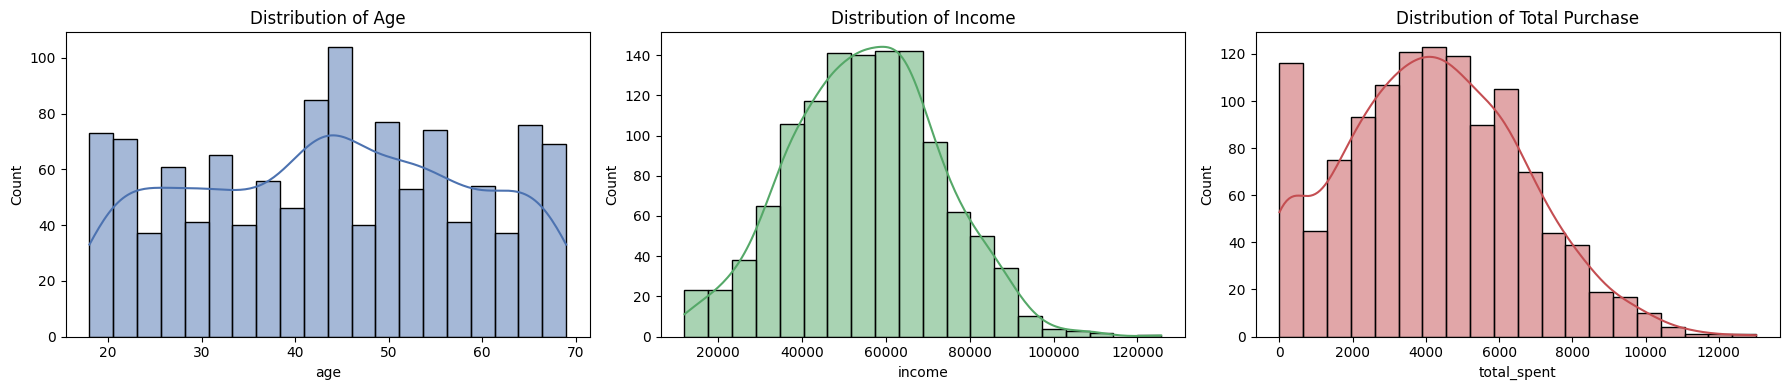

In [35]:
fig, axis = plt.subplots(1, 3, figsize=(18, 4))

sns.histplot(df["age"], bins=20, kde=True, ax=axis[0], color="#4C72B0")
axis[0].set_title("Distribution of Age")

sns.histplot(df["income"], bins=20, kde=True, ax=axis[1], color="#55A868")
axis[1].set_title("Distribution of Income")

sns.histplot(df["total_spent"], bins=20, kde=True, ax=axis[2], color="#C44E52")
axis[2].set_title("Distribution of Total Purchase")

plt.savefig("Images/Univariate_Analysis.png")
plt.tight_layout()
plt.show()

**Interpretation:** Age is fairly uniformly spread across the adult customer base (18-70). Income is approximately normally distributed around ~₹55K with a long right tail. Total spend is right-skewed - most customers spend moderately, with a smaller group of high-value customers.


#### Bivariate Analysis: **Gender vs Purchase** & **Churn vs Income**

C:\Users\Rensee\AppData\Local\Temp\ipykernel_1992\3173074868.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="gender", y="total_spent", palette="Set2", ax=axis[0])
C:\Users\Rensee\AppData\Local\Temp\ipykernel_1992\3173074868.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="churn", y="income", palette="Set2", ax=axis[1])


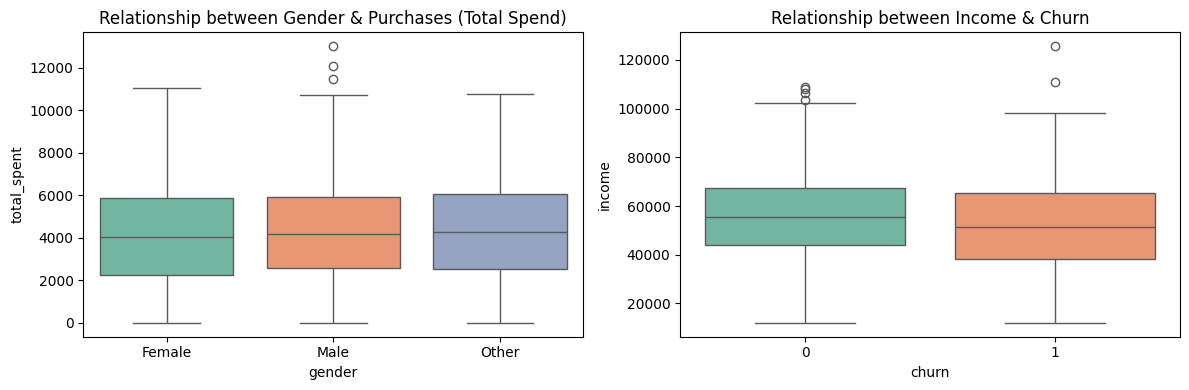

In [40]:
fig, axis = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x="gender", y="total_spent", palette="Set2", ax=axis[0])
axis[0].set_title("Relationship between Gender & Purchases (Total Spend)")

sns.boxplot(data=df, x="churn", y="income", palette="Set2", ax=axis[1])
axis[1].set_title("Relationship between Income & Churn")

plt.savefig("Images/Bivariate_Analysis.png")
plt.tight_layout()
plt.show()

**Interpretation:** Spend distributions are broadly similar across genders, suggesting gender alone is not a strong churn driver. Churned customers skew slightly toward lower income, but the overlap is large - income alone is a weak predictor and needs to be combined with behavioral features.

#### Multivariate Analysis

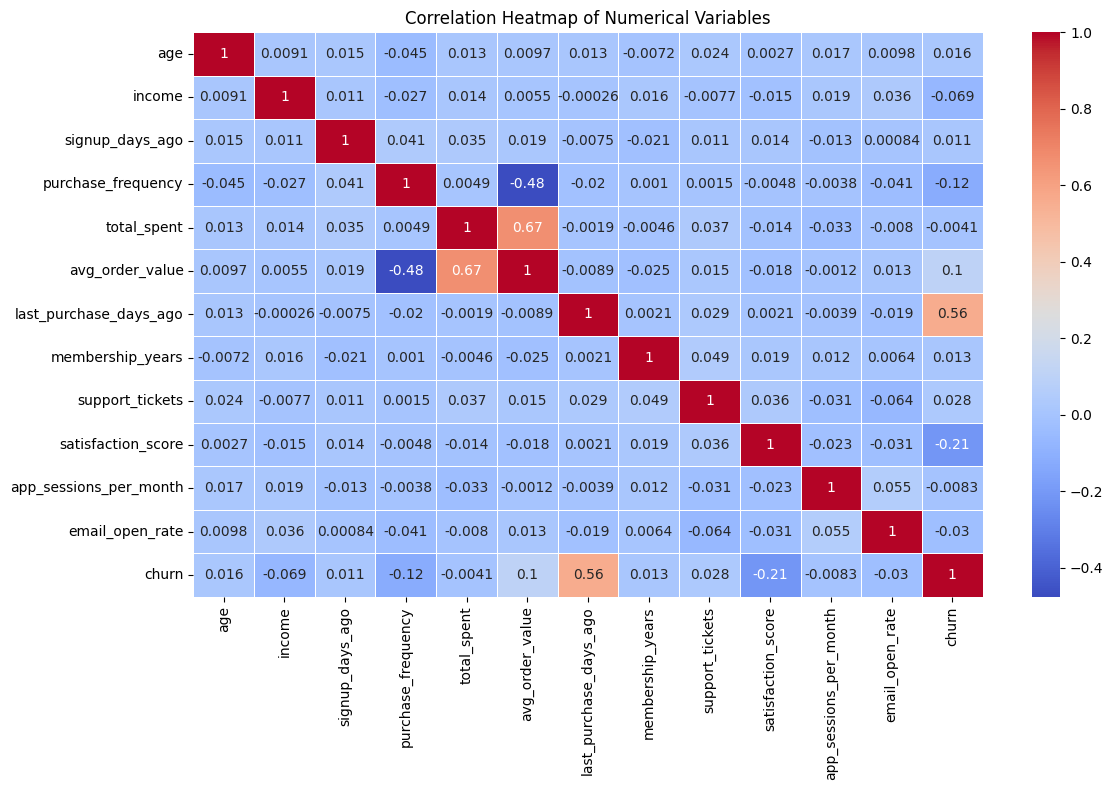

In [37]:
num_col = df.select_dtypes(include="number").columns.to_list()
corr = df[num_col].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Variables")
plt.savefig("Images/Multivariate_Analysis.png")
plt.tight_layout()
plt.show()

**Interpretation:** The correlation heatmap is used to identify linear relationships among numerical variables and potential multicollinearity. The later pair plot indicates that most numeric relationships are low-to-moderate, while churn-related separation is more visible for behavioral variables such as purchase recency and satisfaction.

**Pair Plot**

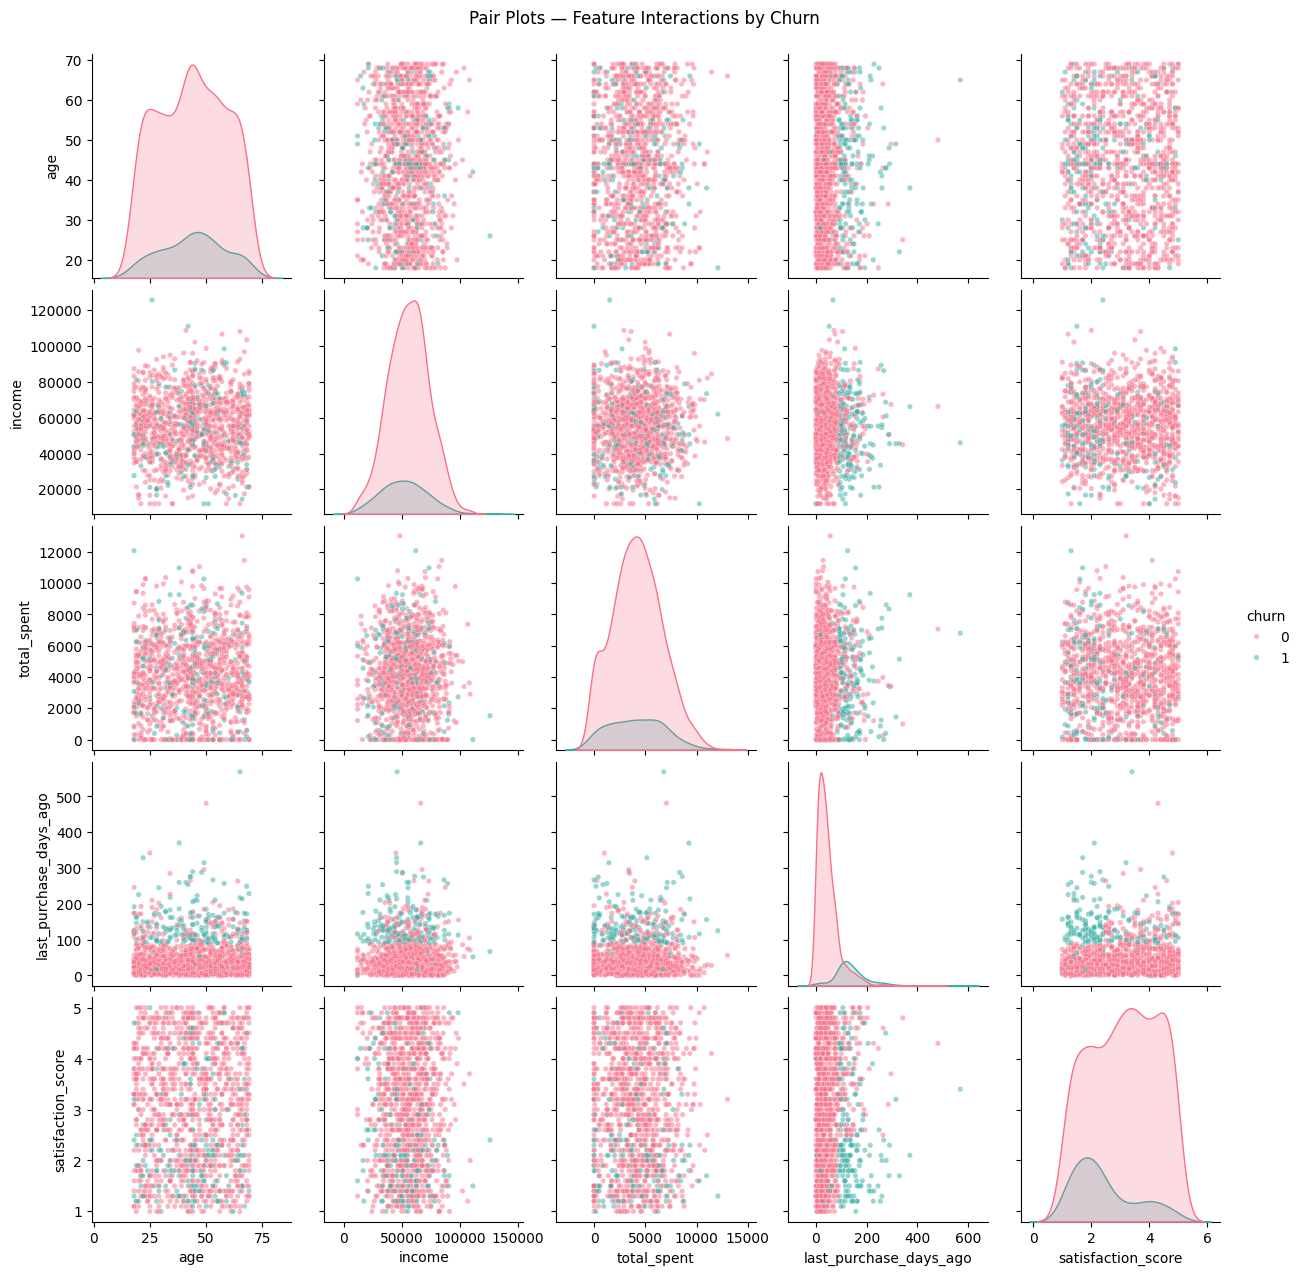

In [38]:
subset_cols = ["age", "income", "total_spent", "last_purchase_days_ago", "satisfaction_score", "churn"]
sns.pairplot(df[subset_cols], hue="churn", diag_kind="kde", palette="husl", plot_kws={"alpha": 0.5, "s": 15})
plt.suptitle("Pair Plots — Feature Interactions by Churn", y=1.02)
plt.savefig("Images/Pair_Plot.png")
plt.show()

**Interpretation:** **last_purchase_days_ago** and **satisfaction_score** show the clearest separation between churned and retained customers, confirming they are the strongest engineered signals for the churn model. Correlations among most numeric features are low-to-moderate, meaning we don't have severe multicollinearity to address before modeling.

---
### Part E : Data Profiling

We generate an automated **profiling report** summarizing missing values, descriptive statistics, correlations, and data quality warnings across the cleaned dataset - useful for a quick, shareable data-quality audit before modeling.


In [42]:
!pip install ydata_profiling
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Customer Churn Dataset - Profiling Report", explorative=True, minimal=False)
profile.to_file("pandas_profiling_report.html")
print("\nProfiling report saved to pandas_profiling_report.html")

Defaulting to user installation because normal site-packages is not writeable


Summarize dataset:  79%|███████▉  | 19/24 [00:00<00:00, 45.93it/s, Calculate auto correlation]C:\Users\Rensee\AppData\Roaming\Python\Python312\site-packages\ydata_profiling\model\pandas\discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[7 9 5 ... 2 9 5]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(
Export report to file: 100%|██████████| 1/1 [00:00<00:00, 26.97it/s]


Profiling report saved to pandas_profiling_report.html


**Interpretation:** The profiling report was generated successfully and saved as an HTML file. It provides an automated overview of distributions, missing values, correlations, and potential data-quality issues, making it useful as a final validation step before feature engineering and model training.

---
## Summary

This notebook walked through the full **Data Profiler** workflow:
 
 **Part A:** Defined data analysis, planned the data science lifecycle, framed the churn ML problem, and explained tensors with NumPy.
 
 **Part B:** Acquired data from four heterogeneous sources - CSV, JSON, SQL, and an APIstyle payload - and merged them into one working table.
 
 **Part C:** Explored structure (.head(), .info(), .describe()), identified missing values/duplicates, and cleaned the dataset.
 
 **Part D:** Performed univariate, bivariate, and multivariate EDA to surface churn related patterns.
 
 **Part E:** Generated an automated profiling report and summarized key data quality findings.

The dataset (df) is now **ML-ready** for the next stage: feature engineering and model training to predict customer churn.
